<a href="https://colab.research.google.com/github/sgisgeodata/sgis-data-manual/blob/main/%EA%B0%9C%EB%B3%84%20%EA%B5%90%EC%9C%A1%EC%9E%90%EB%A3%8C%20Training%20Materials/(260716)%20%EA%B4%91%EC%A3%BC%EC%97%B0%EA%B5%AC%EC%9B%90/GeoAI%20%EC%8B%A4%EC%8A%B5/GeoDeep_building/geodeep_gwangju.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GeoDeep을 활용한 정사영상 객체 탐지 실습

이번 실습에서는 정사영상(GeoTIFF)에 사전학습된 AI 모델을 적용하여 객체를 탐지하고, 결과를 지도 위에 시각화합니다.



## 0. GeoDeep과 GeoAI에 관한 간단한 설명

### 0.1 GeoDeep
[GeoDeep GitHub](https://github.com/uav4geo/GeoDeep)

**GeoDeep**은 GeoTIFF와 같은 지리공간 래스터 데이터를 대상으로 AI 기반 객체탐지를 수행하는 오픈소스 Python 라이브러리입니다. 사전학습된 모델이 포함되어 있어 별도의 모델 학습 없이도 정사영상에서 차량, 도로, 건물 등 특정 객체를 탐지할 수 있습니다.

- **객체탐지(Object Detection)**: `detect()` 함수를 사용하며, 차량이나 항공영상 내 객체를 bounding box 형태로 탐지합니다.
- **의미론적 분할(Semantic Segmentation)**: `segment()` 함수를 사용하며, 건물 또는 도로처럼 일정 영역을 픽셀 단위 마스크로 분할합니다.

### 0.2 GeoAI

[GeoAI GitHub](https://github.com/opengeos/geoai)

**GeoAI**는 위성영상, 항공사진, 벡터 데이터 등을 대상으로 AI 모델 학습, 추론, 데이터 전처리, 시각화 등을 지원하는 Python 라이브러리입니다.

이번 실습에서는 주로 다음 용도로 사용합니다.

- `geoai.raster_to_vector()`: 래스터를 벡터로 변환 (GeoTIFF → GeoJson/GeoDataFrame)
- `geoai.view_vector_interactive()`: 정사영상 위에 벡터 결과 시각화

### 0.3 실습 흐름
이번 실습은 아래 순서로 진행됩니다.

1. 실습 환경 설치 및 라이브러리 불러오기  
2. GitHub에 있는 GeoTIFF 정사영상 불러오기  
3. `segment()` 함수로 이용한 건물 마스크 생성  
4. `detect()` 함수로 객체 탐지
5. GeoAI 라이브러리를 이용하여 지도 위에 결과 시각화


## 1. 실습 환경 설치
먼저 실습에 필요한 Python 패키지를 설치합니다.

In [1]:
# GeoDeep, GeoAI 실습 패키지 설치
!pip install -q -U geodeep rasterio matplotlib geopandas shapely leafmap
!pip install -q -U geoai-py localtileserver


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.3/343.3 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.1/669.1 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 104.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108

## 2. 라이브러리 불러오기
실습에 사용할 주요 라이브러리와 함수를 불러옵니다.

In [10]:
# 기본 라이브러리
import matplotlib.pyplot as plt  # 분석 결과 시각화
import numpy as np               # 배열 데이터 처리
import geopandas as gpd          # 지리정보 데이터 처리
import rasterio                  # GeoTIFF 래스터 데이터 처리
import leafmap                   # 지도 기반 시각화 (배경지도 역할)
from google.colab import files   # Colab 파일 다운로드

# GeoAI
import geoai  # 래스터-벡터 변환 및 시각화

# GeoDeep
from geodeep import segment  # 세그멘테이션 모델
from geodeep import detect   # 객체 탐지 모델
from geodeep.segmentation import save_mask_to_raster  # 마스크 배열을 GeoTIFF로 저장

## 3. 실습용 정사영상 불러오기

이번 실습에서는 GitHub에 저장된 실습용 GeoTIFF 정사영상을 사용합니다.

아래 코드에서는 GitHub Raw URL을 지정한 뒤, geoai.download_file() 함수를 이용해 파일을 Colab 작업공간으로 다운로드합니다.


In [3]:
# 실습용 정사영상 GitHub Raw URL
raster_url = "https://raw.githubusercontent.com/sgisgeodata/sgis-data-manual/main/개별 교육자료 Training Materials/(260716) 광주연구원/GeoAI 실습/GeoDeep_building/buildings.tif"

# 정사영상 다운로드
raster_path = geoai.download_file(raster_url)

실습 데이터는 2025년에 촬영한 광주지역의 정사영상으로, **광주 첨단지구** 일대를 클립한 GeoTIFF 파일입니다.

GeoTIFF는 일반 이미지 파일과 달리 **좌표계(CRS)**
와 위치정보를 포함하고 있어서 지도 위에 시각화하여 어느 위치의 영상인지 확인할 수 있습니다.

`geoai.view_raster()`는 이러한 GeoTIFF 래스터 데이터를 지도 위에서 확인할 수 있도록 도와주는 함수입니다.

In [4]:
# 정사영상 확인 (이미지가 깨지면 재실행 해보기)
geoai.view_raster(raster_url)

## 4. GeoDeep `segment()`로 건물 마스크 생성

`segment()`는 정사영상에서 특정 객체 영역을 픽셀 단위로 분할하는 함수입니다.

여기서 **마스크(mask)**
란 객체가 있는 부분과 없는 부분을 구분한 결과입니다.  
예를 들어 건물 마스크에서는 건물로 판단된 픽셀은 `1`, 건물이 아닌 픽셀은 `0`으로 표현됩니다.


**기본 세그멘테이션 모델**

| 모델명 | 결과 |
|---|---|
| `buildings` | 건물 마스크 |
| `roads` | 도로 마스크 |


### 4.1. 모델 실행

여기서는 `buildings` 모델을 사용하여 건물 후보 영역을 마스크로 생성합니다.

In [5]:
# GeoDeep segmentation 모델 실행
mask = segment(raster_path, 'buildings')

buildings.tif is not tiled. I/O performance will be affected. Consider adding tiles.


### 4.2. 마스크 결과 확인
마스크가 어떤 값으로 구성되어 있는지 확인합니다.

In [11]:
# 마스크 값 확인
print("unique values:", np.unique(mask))

unique values: [0 1]


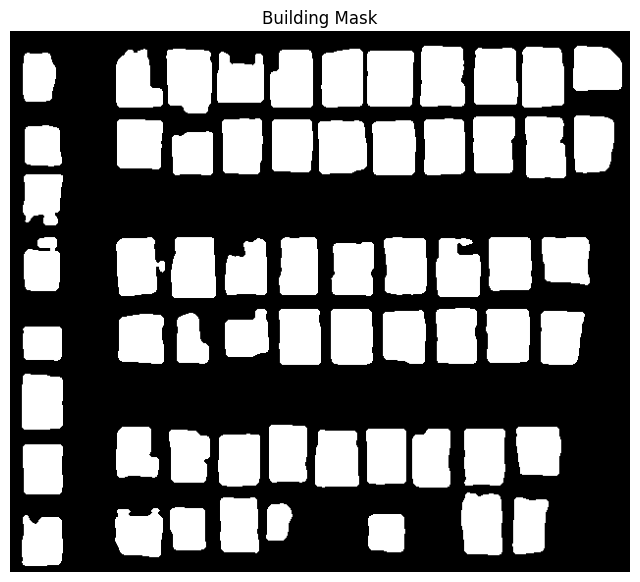

In [66]:
# 마스크 결과 시각화
plt.figure(figsize=(8, 8))
plt.imshow(mask, cmap="gray")
plt.title("Building Mask")
plt.axis("off")
plt.show()

`segment()`의 실행 결과인 마스크는 0 또는 1의 값을 가지는 **numpy 배열**입니다.


In [67]:
print(type(mask))

<class 'numpy.ndarray'>


In [106]:
print(mask)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


### 4.3. 생성된 마스크를 GeoTIFF로 저장

numpy 배열에는 좌표계가 포함되어 있지 않기 때문에 원본 정사영상과 결과를 비교하기 위해서는 좌표정보가 포함된 GeoTIFF 형식으로 변환해야 합니다.

`save_mask_to_raster()` 함수는 원본 GeoTIFF 파일의 좌표계와 위치정보를 참조하여 GeoTIFF 파일을 생성해주는 함수입니다.


In [25]:
# 저장할 파일명 지정
building_mask = "building_mask.tif"

# 마스크 배열을 원본 영상 좌표계가 유지된 GeoTIFF로 저장
save_mask_to_raster(
    raster_path,   # 원본 GeoTIFF 파일 경로
    mask,          # 건물 마스크 배열
    building_mask  #	저장할 GeoTIFF 파일명
)

저장된 `building_mask.tif`에 원본 정사영상과 동일한 좌표계가 부여된 것을 확인할 수 있습니다.

In [108]:
# 좌표계가 부여된 것을 확인
with rasterio.open("buildings.tif") as src:
    print("원본 정사영상 CRS:", src.crs)

with rasterio.open("building_mask.tif") as src:
    print("building_mask CRS:", src.crs)


원본 정사영상 CRS: EPSG:3857
building_mask CRS: EPSG:3857


### 4.4. 마스크 TIFF를 GeoJSON으로 변환

GeoTIFF는 픽셀 기반의 래스터 자료입니다.

이 단계에서는 `geoai.raster_to_vector` 함수를 이용하여 래스터 형태의 건물 마스크를 폴리곤 형태의 벡터 자료인 Geojson 형태로 변환합니다.  
벡터 자료로 변환하면 각 건물 후보 영역을 하나의 폴리곤 객체로 다룰 수 있습니다.


In [36]:
# 저장할 파일명 지정
building_vector = "building.geojson"

# 마스크 래스터를 벡터 폴리곤으로 변환
gdf = geoai.raster_to_vector(
    building_mask,
    building_vector
)

변환 결과는 `GeoDataFrame` 형태의 `gdf` 변수에 저장됩니다.

`GeoDataFrame`은 일반 표처럼 속성정보를 가지고 있으면서, 동시에 `geometry` 컬럼에 공간객체의 위치와 형태 정보를 저장할 수 있는 자료구조입니다. 각 행은 하나의 건물 후보 영역을 나타냅니다.


In [83]:
# 건물 gdf 출력
gdf.head()

,geometry,class
0,"POLYGON ((14122678.377 4192446.095, 14122678.3...",1
1,"POLYGON ((14122506.438 4192443.95, 14122506.43...",1
2,"POLYGON ((14122567.122 4192444.256, 14122567.1...",1
3,"POLYGON ((14122647.422 4192445.482, 14122647.4...",1
4,"POLYGON ((14122613.708 4192444.563, 14122613.7...",1


In [39]:
# 폴리곤 개수 확인
print("건물 폴리곤 개수:", len(gdf))

건물 폴리곤 개수: 62


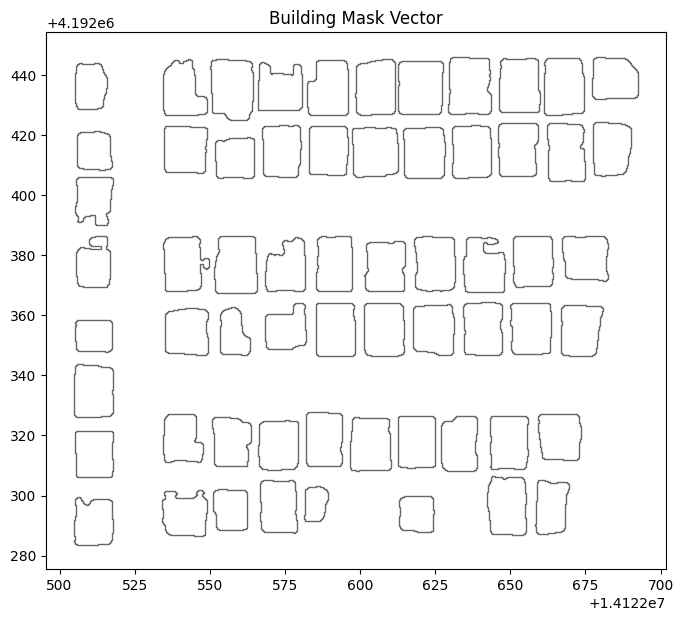

In [93]:
# 건물 폴리곤 시각화
fig, ax = plt.subplots(figsize=(8, 8))

gdf.plot(
    ax=ax,
    figsize=(8, 8),
    facecolor="white",
    edgecolor="black",
    alpha=0.6)

ax.set_title("Building Mask Vector")
plt.show()

### 4.4. 건물 마스크 결과를 지도 위에 시각화

`view_vector_interactive()`를 사용하면 원본 정사영상 위에 GeoJSON 벡터를 겹쳐 볼 수 있습니다.

- `gdf`: 방금 만든 건물 폴리곤
- `tiles=raster_url`: 배경으로 사용할 원본 정사영상


In [99]:
# 원본 정사영상 위에 건물 폴리곤 시각화
geoai.view_vector_interactive(
    gdf,
    tiles=raster_url
)


## 5. GeoDeep `detect()`로 객체 탐지 실행

`detect()`는 객체별 위치를 **박스 또는 폴리곤 형태의 GeoJSON**으로 반환합니다.  
즉, `segment()`처럼 픽셀 마스크를 만드는 것이 아니라, 탐지된 객체의 경계와 속성값(class)을 저장합니다.

### 5.1. 모델 실행

실습에서는 여러 객체 클래스를 탐지할 수 있는 `waldo30_nano` 모델을 사용합니다.


In [42]:
# GeoDeep object detection 모델 실행
waldo_geojson = detect(
    raster_path,
    "waldo30_nano",
    output_type="geojson"
)


buildings.tif is not tiled. I/O performance will be affected. Consider adding tiles.


### 5.2. 탐지 GeoJSON을 GeoDataFrame으로 읽기

저장한 GeoJSON을 `geopandas`로 읽어 `gdf_waldo`를 만듭니다.  

In [43]:
# GeoJSON 파일을 GeoDataFrame으로 읽기
gdf_waldo = gpd.read_file(waldo_geojson)

In [44]:
# gdf_waldo 출력
gdf_waldo.head()

,score,class,geometry
0,0.328305,building,"POLYGON ((126.86569 35.20891, 126.86585 35.208..."
1,0.416236,building,"POLYGON ((126.86459 35.20996, 126.86472 35.209..."
2,0.865986,building,"POLYGON ((126.86587 35.20993, 126.86602 35.209..."
3,0.844114,building,"POLYGON ((126.86532 35.20933, 126.86547 35.209..."
4,0.647553,building,"POLYGON ((126.86573 35.20993, 126.86587 35.209..."


In [45]:
# 탐지 객체 수 확인
print("탐지 객체 수:", len(gdf_waldo))

탐지 객체 수: 177


In [46]:
# 클래스별 탐지 개수 확인
if "class" in gdf_waldo.columns:
    print(gdf_waldo["class"].value_counts())

class
light-vehicle    112
building          65
Name: count, dtype: int64


### 5.3. 객체 탐지 결과 시각화

탐지 결과에 `class` 컬럼이 있으면 객체 종류별로 색상을 구분해서 볼 수 있습니다.  

In [98]:
# 원본 정사영상 위에 객체 탐지 결과 시각화
geoai.view_vector_interactive(
    gdf_waldo,
    column="class",
    tiles=raster_url
)

## 6. 결과 저장 후 QGIS에 불러오기
분석 결과를 QGIS에서 확인할 수 있도록 GeoPackage(`.gpkg`) 형식으로 저장합니다.  

In [ ]:
# QGIS용 GeoPackage 저장
gdf.to_file("building_result.gpkg", layer="building", driver="GPKG")
gdf_waldo.to_file("waldo_result.gpkg", layer="waldo", driver="GPKG")

In [ ]:
files.download("buildings.tif")
files.download("building_result.gpkg")
files.download("waldo_result.gpkg")

## 7. 모델을 바꿔가며 실습하기

GeoDeep에서는 크게 두 가지 방식의 모델을 사용합니다.

### 1) 마스크를 만드는 세그멘테이션 모델

```python
mask = segment(raster_path, "buildings")
mask = segment(raster_path, "roads")
```

### 2) 객체 탐지 하는 모델

```python
geojson = detect(raster_path, "cars", output_type="geojson")
geojson = detect(raster_path, "aerovision", output_type="geojson")
geojson = detect(raster_path, "waldo30_nano", output_type="geojson")
```


## 실습 내용 정리

1. GitHub의 GeoTIFF를 Colab에서 불러오기
2. GeoDeep `segment()`를 이용한 마스크 생성
3. GeoDeep `detect()`를 이용한 객체탐지
4. GeoAI를 이용한 마스크의 GeoJSON 변환
5. 원본 정사영상 위 결과 시각화

사전학습 모델은 영상 해상도와 촬영 지역에 따라 결과가 달라질 수 있으므로, 실습 결과는 모델 적용 가능성을 확인하는 예시로 해석합니다.
